<a href="https://colab.research.google.com/github/mrvamsi4/minor-project-/blob/main/Retail_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd

df = pd.read_csv("retail_customer_data.csv")

print(df.head())


  CustomerID  Age  Gender  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
0   CUST1001   25    Male        121861                 15           4660   
1   CUST1002   52    Male        116965                 18           4503   
2   CUST1003   47  Female        124529                 19           5471   
3   CUST1004   39    Male        109104                 25           4088   
4   CUST1005   38    Male        117188                 23           3106   

   TotalSpend  RecencyDays  DiscountUsagePct  OnlinePurchases  StorePurchases  \
0       68825            6                 0               12               3   
1       90148           13                 0                7              11   
2      100267           11                12                3              16   
3      114096           17                12               15              10   
4       72191           11                11               17               6   

  PreferredCategory       City  Cluster      PCA1 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("retail_customer_data.csv")

In [5]:
print(df.head())

  CustomerID  Age  Gender  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
0   CUST1001   25    Male        121861                 15           4660   
1   CUST1002   52    Male        116965                 18           4503   
2   CUST1003   47  Female        124529                 19           5471   
3   CUST1004   39    Male        109104                 25           4088   
4   CUST1005   38    Male        117188                 23           3106   

   TotalSpend  RecencyDays  DiscountUsagePct  OnlinePurchases  StorePurchases  \
0       68825            6                 0               12               3   
1       90148           13                 0                7              11   
2      100267           11                12                3              16   
3      114096           17                12               15              10   
4       72191           11                11               17               6   

  PreferredCategory       City  Cluster      PCA1 

In [6]:
print(df.head())

  CustomerID  Age  Gender  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
0   CUST1001   25    Male        121861                 15           4660   
1   CUST1002   52    Male        116965                 18           4503   
2   CUST1003   47  Female        124529                 19           5471   
3   CUST1004   39    Male        109104                 25           4088   
4   CUST1005   38    Male        117188                 23           3106   

   TotalSpend  RecencyDays  DiscountUsagePct  OnlinePurchases  StorePurchases  \
0       68825            6                 0               12               3   
1       90148           13                 0                7              11   
2      100267           11                12                3              16   
3      114096           17                12               15              10   
4       72191           11                11               17               6   

  PreferredCategory       City  Cluster      PCA1 

In [7]:
print(df.shape)

(600, 17)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         600 non-null    object 
 1   Age                600 non-null    int64  
 2   Gender             600 non-null    object 
 3   AnnualIncome       600 non-null    int64  
 4   PurchaseFrequency  600 non-null    int64  
 5   AvgOrderValue      600 non-null    int64  
 6   TotalSpend         600 non-null    int64  
 7   RecencyDays        600 non-null    int64  
 8   DiscountUsagePct   600 non-null    int64  
 9   OnlinePurchases    600 non-null    int64  
 10  StorePurchases     600 non-null    int64  
 11  PreferredCategory  600 non-null    object 
 12  City               600 non-null    object 
 13  Cluster            600 non-null    int64  
 14  PCA1               600 non-null    float64
 15  PCA2               600 non-null    float64
 16  Segment            600 non

In [9]:
df.describe()

,Age,AnnualIncome,PurchaseFrequency,AvgOrderValue,TotalSpend,RecencyDays,DiscountUsagePct,OnlinePurchases,StorePurchases,Cluster,PCA1,PCA2
count,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,40.348333,68787.946667,9.79000,2138.281667,27401.116667,36.980000,34.053333,5.433333,4.356667,0.253333,0.000000,0.000000
std,11.155615,29735.023350,5.93053,1312.606166,29898.481211,25.790661,17.958787,4.084118,3.585743,0.435283,2.259401,0.704577
min,22.000000,28424.000000,1.00000,617.000000,933.000000,3.000000,0.000000,0.000000,0.000000,0.000000,-3.078636,-1.348996
25%,30.750000,44461.000000,5.00000,1063.500000,4985.250000,16.000000,18.750000,2.000000,2.000000,0.000000,-1.895728,-0.613357
50%,40.000000,61118.500000,8.50000,1560.500000,11364.500000,29.500000,36.000000,4.000000,3.000000,0.000000,-0.637602,-0.153326
75%,49.250000,90019.250000,14.00000,2855.500000,38064.750000,51.000000,49.000000,8.000000,6.000000,1.000000,1.430546,0.548154
max,60.000000,155211.000000,26.00000,5618.000000,120000.000000,107.000000,72.000000,20.000000,21.000000,1.000000,4.972005,1.821395


In [10]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
AnnualIncome,0
PurchaseFrequency,0
AvgOrderValue,0
TotalSpend,0
RecencyDays,0
DiscountUsagePct,0
OnlinePurchases,0


In [11]:
df.duplicated().sum()

np.int64(0)

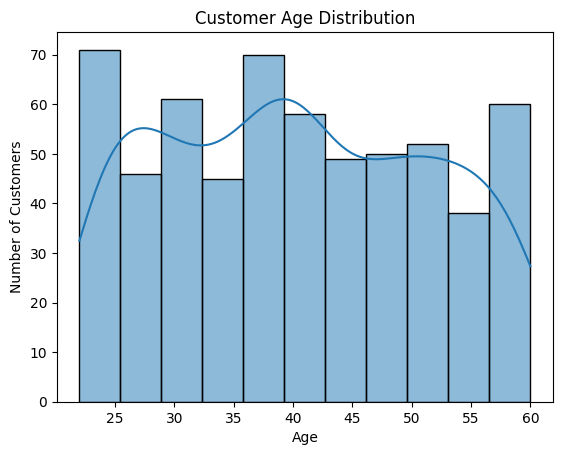

In [12]:
sns.histplot(df["Age"], kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

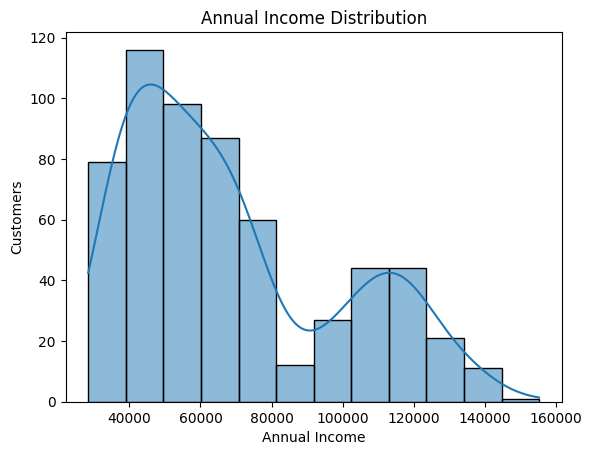

In [13]:
sns.histplot(df["AnnualIncome"], kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Customers")

plt.show()

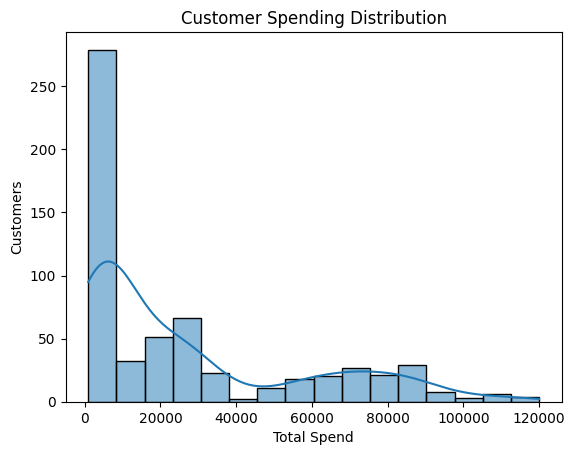

In [14]:
sns.histplot(df["TotalSpend"], kde=True)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Customers")

plt.show()

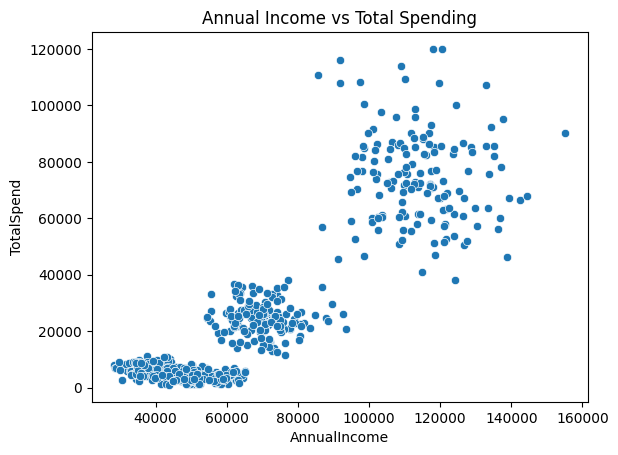

In [15]:
sns.scatterplot(
    data=df,
    x="AnnualIncome",
    y="TotalSpend"
)

plt.title("Annual Income vs Total Spending")
plt.show()

In [16]:
features = [
    "AnnualIncome",
    "PurchaseFrequency",
    "AvgOrderValue",
    "TotalSpend",
    "RecencyDays",
    "DiscountUsagePct"
]

X = df[features]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

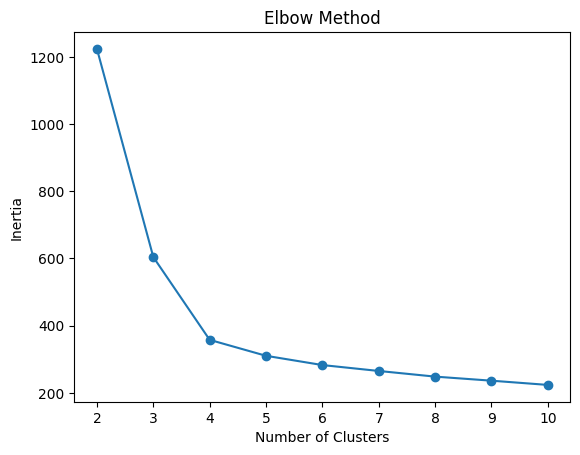

In [19]:
plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [20]:
silhouette_scores = {}

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores[k] = score

    print(k, score)

2 0.5943385595958012
3 0.537733181114077
4 0.5601198443304181
5 0.47777918673002034
6 0.41385726973051273


In [21]:
best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print("Best K:", best_k)

Best K: 2


In [22]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [23]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

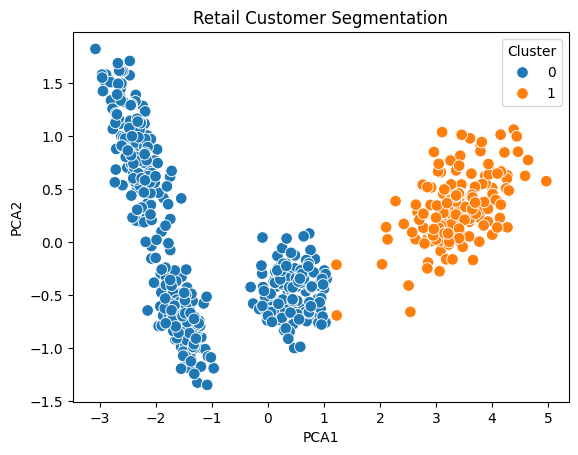

In [24]:
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    s=70
)

plt.title("Retail Customer Segmentation")
plt.show()

In [25]:
cluster_summary = df.groupby("Cluster")[features].mean()

print(cluster_summary)

          AnnualIncome  PurchaseFrequency  AvgOrderValue    TotalSpend  \
Cluster                                                                  
0         53540.252232           6.977679    1453.912946  11483.446429   
1        113728.519737          18.078947    4155.368421  74316.355263   

         RecencyDays  DiscountUsagePct  
Cluster                                 
0          46.087054         41.540179  
1          10.138158         11.986842  


In [26]:
df.to_csv(
    "customer_segments.csv",
    index=False
)

In [27]:
cluster_summary.to_csv(
    "cluster_summary.csv"
)